In [ ]:
#Uploding file to google collab
from google.colab import files
uploaded = files.upload()
import pandas as pd



Saving Fashion_Retail_Sales.csv to Fashion_Retail_Sales (1).csv


Dataset Shape: (3400, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB
None
        Customer Reference ID Item Purchased  Purchase Amount (USD)  \
count             3400.000000           3400            2750.000000   
unique                    NaN             50                    NaN   
top                       NaN           Belt                    NaN   
freq                      NaN             90                    NaN   
mean              4039.660588

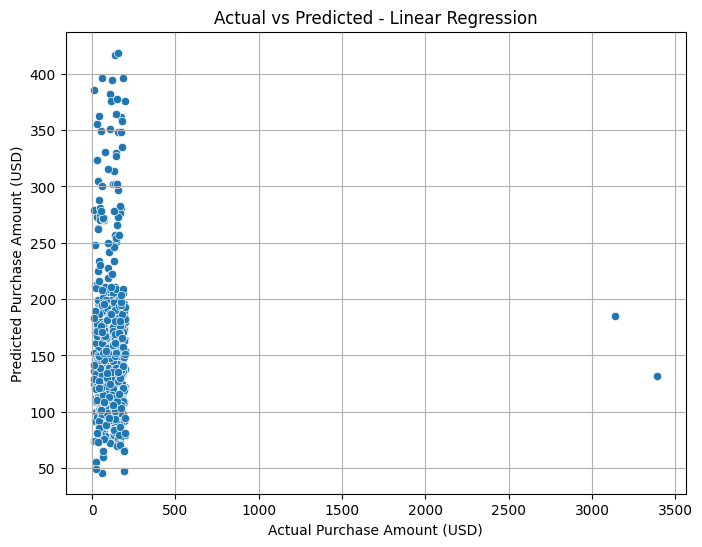

In [ ]:
# 📦 Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📂 Load the dataset
df = pd.read_csv("Fashion_Retail_Sales.csv")

# 📋 Basic info
print("Dataset Shape:", df.shape)
print(df.info())
print(df.describe(include='all'))

# 🧹 Drop rows with missing target or important feature
df_clean = df.dropna(subset=["Purchase Amount (USD)", "Review Rating"])

# 🧠 One-hot encode categorical features
df_encoded = pd.get_dummies(df_clean, columns=["Item Purchased", "Payment Method"], drop_first=True)

# 🧮 Define features (X) and target (y)
X = df_encoded.drop(columns=["Customer Reference ID", "Date Purchase", "Purchase Amount (USD)"])
y = df_encoded["Purchase Amount (USD)"]

# 🔀 Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🧪 Build and Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 🎯 Make Predictions
y_pred = model.predict(X_test)

# 📊 Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# 📝 Print Results
print("\n📈 Linear Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f} USD")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} USD")
print(f"R² Score: {r2:.3f}")

# 🔍 Optional: Visualizing Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Purchase Amount (USD)")
plt.ylabel("Predicted Purchase Amount (USD)")
plt.title("Actual vs Predicted - Linear Regression")
plt.grid(True)
plt.show()


###Conclusion

Here in our linear regression model we have low R square value meaning this model is not ideal for our dataset and we should focus on testing in other models like decision tree ,random tree etc.